In [3]:
import pandas as pd

In [4]:
day_minus_1 = pd.read_csv('../../round_data/prices_round_2_day_-1.csv', delimiter=';')
day_0 = pd.read_csv('../../round_data/prices_round_2_day_0.csv', delimiter=';')
day_plus_1 = pd.read_csv('../../round_data/prices_round_2_day_1.csv', delimiter=';')

In [5]:
day_0.timestamp += 1e6
day_plus_1.timestamp += 2*1e6

In [6]:
data = pd.concat([day_minus_1, day_0, day_plus_1], axis=0)

In [7]:
data['product'].value_counts()

product
CROISSANTS          30000
JAMS                30000
SQUID_INK           30000
PICNIC_BASKET1      30000
PICNIC_BASKET2      30000
RAINFOREST_RESIN    30000
DJEMBES             30000
KELP                30000
Name: count, dtype: int64

In [8]:
# Components: 6 croissants, 3 jams, 1 djembe
picnic_1 = data[data['product']=='PICNIC_BASKET1'].reset_index(drop=True)
# Components: 4 croissants, 2 jams
picnic_2 = data[data['product']=='PICNIC_BASKET2'].reset_index(drop=True)

croissants = data[data['product']=="CROISSANTS"].reset_index(drop=True)
jams = data[data['product']=="JAMS"].reset_index(drop=True)
djembe = data[data['product']=='DJEMBES'].reset_index(drop=True)

In [9]:
import matplotlib.pyplot as plt

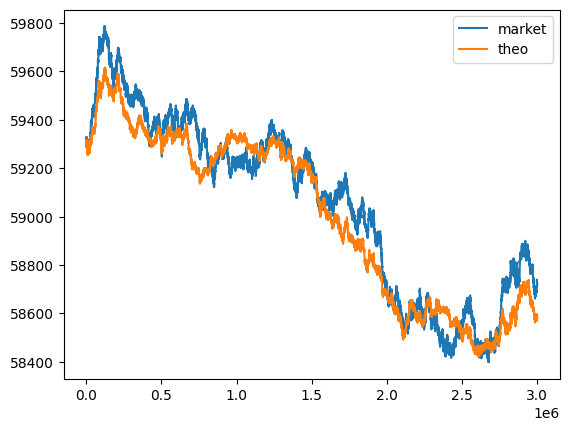

In [10]:
plt.plot(picnic_1.timestamp,picnic_1.mid_price, label='market')
theo_basket = 6*croissants.mid_price+3*jams.mid_price+djembe.mid_price
plt.plot(picnic_1.timestamp, theo_basket, label='theo')
plt.legend()

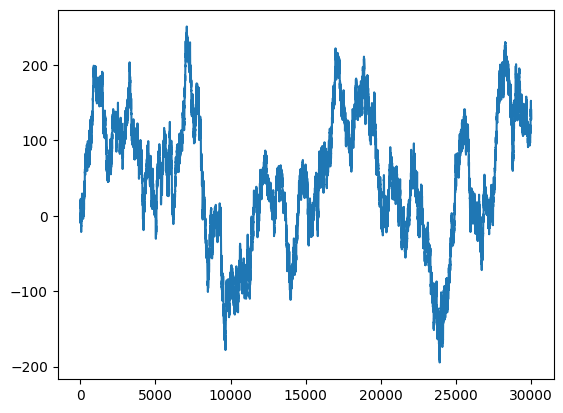

In [ ]:
plt.plot(picnic_1.mid_price - theo_basket)

# plt.axhline((picnic_1.mid_price - theo_basket).std())
# plt.axhline((picnic_1.mid_price - theo_basket).mean())
# (picnic_1.mid_price-theo_basket).rolling(45).std()

In [ ]:
roling_std = (picnic_1.mid_price-theo_basket).rolling(45).std()
((picnic_1.mid_price-theo_basket)-)/rolling_std

(array([0.00555491, 0.01785505, 0.04880381, 0.08451392, 0.09006882,
        0.07895901, 0.04602636, 0.01587116, 0.0075388 , 0.00158712]),
 array([-11.21924344,  -8.69894849,  -6.17865353,  -3.65835857,
         -1.13806362,   1.38223134,   3.9025263 ,   6.42282126,
          8.94311621,  11.46341117,  13.98370613]),
 <BarContainer object of 10 artists>)

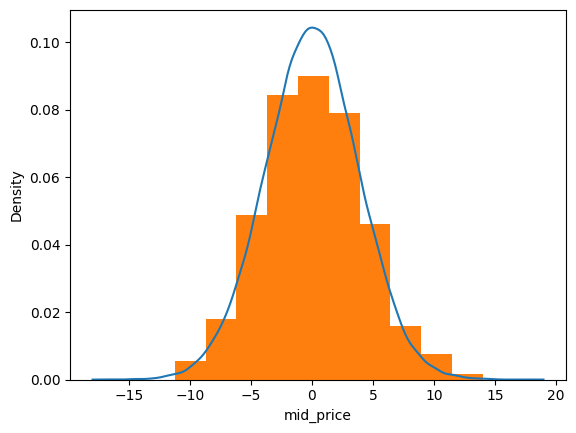

In [22]:
# plt.plot((picnic_1.mid_price - theo_basket).diff())
import seaborn as sns
fig,ax = plt.subplots()
sns.kdeplot((picnic_1.mid_price - theo_basket).diff(), ax=ax)
import numpy as np
ax.hist(np.random.standard_normal(1000)*4,density=True)

In [23]:
(picnic_1.mid_price - theo_basket).diff().std()

3.8270969850421177

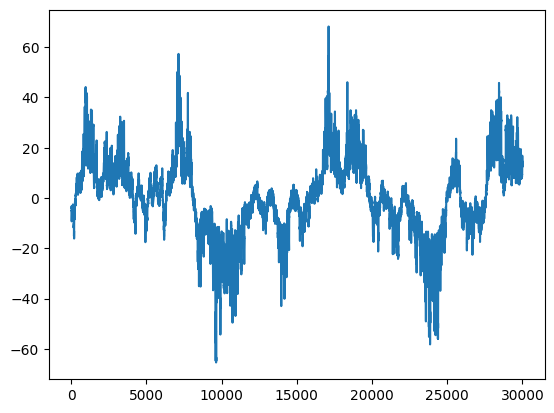

In [43]:
mu = (picnic_1.mid_price-theo_basket).mean()
sig = (picnic_1.mid_price-theo_basket).rolling(30).std()
plt.plot((picnic_1.mid_price-theo_basket-mu)/sig)

In [28]:
theo_basket = 4*croissants.mid_price+2*jams.mid_price

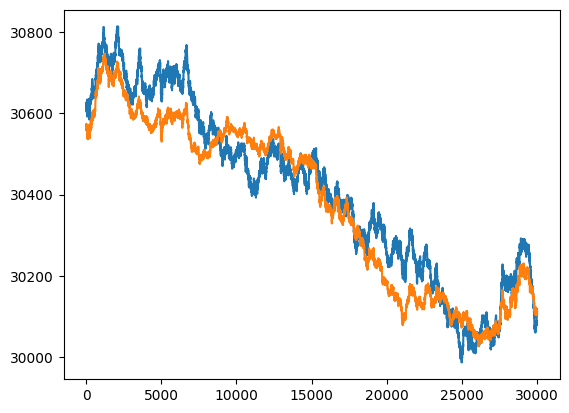

In [29]:
plt.plot(picnic_2.mid_price)
plt.plot(theo_basket)

59.849200222652364
30.235966666666666


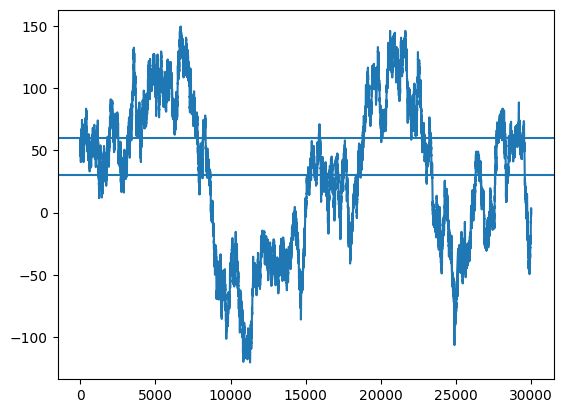

In [30]:
plt.plot(picnic_2.mid_price - theo_basket)

plt.axhline((picnic_2.mid_price - theo_basket).std())
print((picnic_2.mid_price - theo_basket).std())
plt.axhline((picnic_2.mid_price - theo_basket).mean())
print((picnic_2.mid_price - theo_basket).mean())

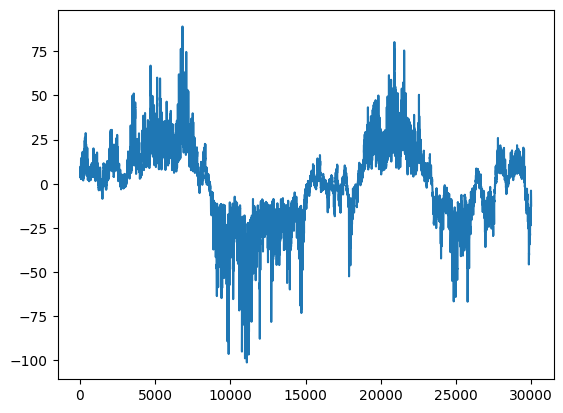

In [34]:
mu = (picnic_2.mid_price-theo_basket).mean()
sig = (picnic_2.mid_price-theo_basket).rolling(20).std()
plt.plot((picnic_2.mid_price-theo_basket-mu)/sig)